# Logistic Regression: Batch GD, Stochastic GD, Mini-batch GD 비교 (make_moons 데이터셋)

이번 실습에서는 **make_moons 데이터셋**을 사용하여 Logistic Regression을 학습합니다.
그리고 Gradient Descent 방식 (Batch, Stochastic, Mini-batch)에 따른 차이를 비교합니다.


In [7]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

In [14]:
# matplotlib 폰트 깨짐 현상 해결
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf')
plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False # Enable negative sign for Korean fonts

In [15]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## 1. 데이터 생성 및 전처리

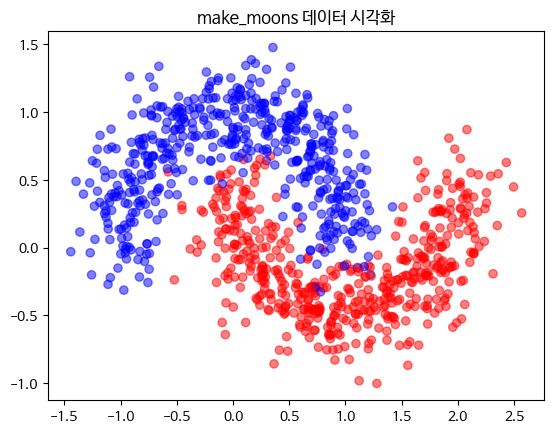

In [16]:
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", alpha=0.5)
plt.title("make_moons 데이터 시각화")
plt.show()

## 2. 학습 함수 정의

In [17]:
def train_logistic(X, y, epochs=50, lr=0.1, batch_size=None):
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(shape=(X.shape[1],)),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=lr),
                  loss="binary_crossentropy",
                  metrics=["accuracy"])
    history = model.fit(X, y,
                        epochs=epochs,
                        batch_size=batch_size,
                        verbose=0,
                        validation_split=0.2)
    return history, model

## 3. Batch GD 학습 (전체 데이터 사용)

In [18]:
history_batch, model_batch = train_logistic(
    X_train, y_train, epochs=100, lr=0.1, batch_size=len(X_train)
)

## 4. Stochastic GD 학습 (batch_size=1)

In [19]:
history_sgd, model_sgd = train_logistic(
    X_train, y_train, epochs=100, lr=0.1, batch_size=1
)

## 5. Mini-batch GD 학습 (batch_size=32)

In [20]:
history_mini, model_mini = train_logistic(
    X_train, y_train, epochs=100, lr=0.1, batch_size=32
)

## 6. Loss 비교 시각화

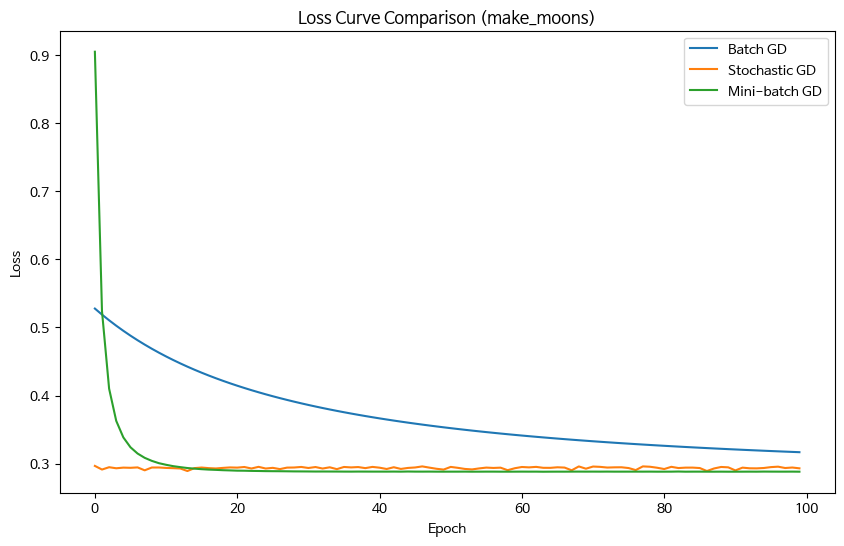

In [21]:
plt.figure(figsize=(10, 6))
plt.plot(history_batch.history["loss"], label="Batch GD")
plt.plot(history_sgd.history["loss"], label="Stochastic GD")
plt.plot(history_mini.history["loss"], label="Mini-batch GD")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss Curve Comparison (make_moons)")
plt.show()

## 7. 최종 정확도 비교

In [22]:
print("Batch GD 정확도:", model_batch.evaluate(X_test, y_test, verbose=0)[1])
print("Stochastic GD 정확도:", model_sgd.evaluate(X_test, y_test, verbose=0)[1])
print("Mini-batch GD 정확도:", model_mini.evaluate(X_test, y_test, verbose=0)[1])

Batch GD 정확도: 0.824999988079071
Stochastic GD 정확도: 0.8650000095367432
Mini-batch GD 정확도: 0.8500000238418579


## 생각해보기
- 각 GD 방식의 장단점은 무엇일까요?
    - Batch GD
      - 장점
        - 안정적인 수렴 : 모든 데이터를 사용하므로 일관된 방향으로 학습
        - 부드러운 손실 곡선 : 노이즈가 적고 예측 가능한 학습 과정
        - 정확한 기울기 : 전체 데이터셋의 실제 기울기를 계산
        - 벡터화 연산 효율성 : GPU 활용 시 병렬 처리 효과 극대화
      - 단점
       - 메모리 사용량 과다 : 대용량 데이터셋에서 메모리 부족 위험
       - 느린 업데이트 : 한 번의 업데이트를 위해 전체 데이터 처리 필요
       - Local minima 탈출 어려움 : 안정적이지만 최적해를 놓칠 수 있음

    - Stochastic GD
      - 장점
        - 빠른 초기 학습 : 매 샘플마다 즉시 가중치 업데이트
        - 메모리 효율성 : 한 번에 하나의 샘플만 처리
        - Local minima 탈출 가능 : 노이즈가 최적화에 도움이 될 수 있음
        - 온라인 학습 지원 : 실시간 데이터 스트림 처리 가능
      - 단점
        - 불안정한 수렴 : 손실 함수가 진동하며 수렴 속도 저하
        - 높은 분산 : 개별 샘플의 노이즈로 인한 학습 불안정
        - 느린 전체 수렴 : 최종 수렴까지 많은 에포크 필요
        - 하이퍼파라미터 민감성 : 학습률 조정이 매우 중요

    - Mini-batch GD
     - 장점
      - 균형잡힌 성능 : 배치와 SGD의 장점을 결합
      - 안정적이면서도 효율적 : 적당한 노이즈로 local minima 탈출 가능
      - GPU 최적화 : 적절한 배치 크기로 하드웨어 효율성 극대화
      - 실용적 메모리 사용 : 메모리 제약 내에서 최적 성능
    - 단점
      - 하이퍼파라미터 조정 : 배치 크기라는 추가 파라미터 필요
      - 상황 의존적 : 데이터셋과 문제에 따라 최적 배치 크기 상이
      
    - 실무 관점에서의 선택 기준
      - 소규모 데이터 ( < 10,000) : Batch GD 권장
      - 대규모 데이터 ( > 1,000,000) : Mini-batch GD (배치 크기 32-512)
      - 실시간 학습 : Stochastic GD
      - GPU 활용 : Mini-batch GD (GPU 메모리에 맞는 배치 크기)